In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import sys
import shutil

sys.path.append('../..')
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()
from copy import copy

def gaussian_model(x, mu, sigma):
    y = np.exp(-0.5*(x-mu)**2 / sigma**2)
    return y/np.max(y)

In [2]:
from src import IOFunctions

IO = IOFunctions.IO_Functions()

In [3]:
R, G, B, wavelength = S_F.getpixelefficiency('../../Spectra/Camera_QE/CS505CU_QE.csv')

In [4]:
cameras = ['Camera_Normal', 'Camera_Sharp', 'Camera_Broad']

R_nonsharp = np.max(G)*gaussian_model(wavelength, 650, 500)
G_nonsharp = np.max(G)*gaussian_model(wavelength, 650, 500)
B_nonsharp = np.max(G)*gaussian_model(wavelength, 650, 500)

R_sharp = copy(R)
G_sharp = copy(G)
B_sharp = copy(B)
B_sharp[wavelength < 500] = np.max(G)
B_sharp[wavelength >= 500] = 0
G_sharp[(wavelength < 500) | (wavelength > 600)] = 0
G_sharp[(wavelength < 600) & (wavelength >= 500)] = np.max(G)
R_sharp[wavelength < 600] = 0
R_sharp[wavelength >= 600] = np.max(G)

wavelength = wavelength
pixel_QYs_normal = np.vstack([B, G, R])
pixel_QYs_broad = np.vstack([B_nonsharp, G_nonsharp, R_nonsharp])
pixel_QYs_sharp = np.vstack([B_sharp, G_sharp, R_sharp])

In [5]:
# values of phootns are per 100 ms from Steen, P. R. et al. The DNA-PAINT palette: a comprehensive performance analysis of fluorescent dyes. Nat Methods 21, 1755–1762 (2024).
# or from Dempsey, G. T., Vaughan, J. C., Chen, K. H., Bates, M. & Zhuang, X. Evaluation of fluorophores for optimal performance in localization-based super-resolution imaging. Nat Methods 8, 1027–1036 (2011).
single_molecule_dyes = np.array([['ATTO 488', 2073, 0.8],
                                 ['Alexa Fluor 488', 2811, 0.92],
                                 ['Abberior Star 488', 2969, 0.89],
                                 ['CF488A', 3879, 0.9],
                                 ['Cy3B', 23195, 0.58],
                                 ['ATTO 565', 11600, 0.9],
                                 ['Janelia Fluor JF585-HaloTag conjugate', 2429, 0.78],
                                 ['CF568', 13388, 0.9],
                                 ['Cy5', 7801, 0.27],
                                 ['Cy5B', 17090, 0.4],
                                 ['ATTO 643', 23327, 0.62],
                                 ['ATTO 647N', 18448, 0.65],
                                 ['ATTO 655', 8273, 0.3],
                                 ['CF640R', 12024, 0.3],
                                 ['CF660R', 10399, 0.3],
                                 ['abberior STAR 635', 12731, 0.9],
                                 ['Janelia Fluor JF646-HaloTag conjugate', 14440, 0.54],
                                 ['Alexa Fluor 647', 10348, 0.33],
                                 ['Cy2', 6241, 0.12],
                                 ['Cy3', 11022, 0.15],
                                 ['Tetramethylrhodamine (TAMRA, TRITC)', 4884, 0.2],
                                 ['Cy3.5', 4968, 0.15],
                                 ['ATTO 647', 1526, 0.2],
                                 ['ATTO 680', 1656, 0.3],
                                 ['Cy5.5', 6337, 0.28],
                                 ['Cy7', 852, 0.28],
                                 ['Alexa Fluor 750', 703, 0.12],
                                 ['ATTO 740', 779, 0.1],
                                 ['Alexa Fluor 790', 740, 0.1]], dtype='object')


In [6]:
single_molecule_dataset = pl.DataFrame(data=single_molecule_dyes, schema=['dye', 'photons', 'QY'])

In [7]:
corrected_photons_normal = np.zeros(len(single_molecule_dyes))
corrected_photons_bayer = np.zeros(len(single_molecule_dyes))
corrected_photons_sharp = np.zeros(len(single_molecule_dyes))
average_emission_wavelength = np.zeros(len(single_molecule_dyes))

In [8]:
# Import the new refactored classes
from src.SpectralFunctions import (SpectralDataType
)

In [17]:
efficiency

array([ 0.28676693,  0.22377332,  0.22377332,  0.18515611])

In [10]:
for dyeval in np.arange(len(single_molecule_dataset)):
    dye = single_molecule_dataset['dye'].to_numpy()[dyeval]
    if dye == 'Abberior Star 488':
        dyestr = 'Alexa Fluor 488'
    else:
        dyestr = dye
    photonval = single_molecule_dataset['photons'].to_numpy()[dyeval]
    dye_spectrum = S_F.get_dye_or_filter_data(dyestr, wavelength)
    average_emission_wavelength[dyeval] = S_F.moment_calculations(x=wavelength, fx=dye_spectrum)[1]
    _, efficiency = S_F.get_pixel_fractions_dye_and_filters(dyes=dyestr, filters=[], wavelength=wavelength,
                                                            pixel_QYs=np.vstack([R, G, G, B]))
    corrected_photons_bayer[dyeval] = np.mean(photonval * efficiency)
    _, efficiency_sharp = S_F.get_pixel_fractions_dye_and_filters(dyes=dyestr, filters=[], wavelength=wavelength, 
                                                            pixel_QYs=np.vstack([R_sharp, G_sharp, G_sharp, B_sharp]))
    corrected_photons_sharp[dyeval] = np.mean(photonval * efficiency_sharp)
    _, efficiency_broad = S_F.get_pixel_fractions_dye_and_filters(dyes=dyestr, filters=[], wavelength=wavelength, 
                                                            pixel_QYs=np.vstack([G_nonsharp, G_nonsharp, G_nonsharp, G_nonsharp]))
    corrected_photons_normal[dyeval] = np.mean(photonval * efficiency_broad)

/tmp/ipykernel_528205/3074927911.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  average_emission_wavelength[dyeval] = S_F.moment_calculations(x=wavelength, fx=dye_spectrum)[1]


In [11]:
corrected_photons_bayer

array([  739.20145485,  1010.96396801,  1067.78798328,  1424.15223456,
        6896.89038788,  3412.12288699,   669.71395651,  4207.41202093,
        1566.00912985,  3460.59490967,  4792.42795671,  3756.60792061,
        1703.45546309,  2443.16726683,  2139.36985874,  2617.57846856,
        2912.36690668,  2105.35692231,  2227.65859199,  3561.62449674,
        1509.11542827,  1403.62520864,   313.31523506,   347.80572955,
        1321.32228975,   187.03136876,   154.23912221,   159.01900577,
         170.10189332])

In [12]:
columns = ['dye', 'photons', 'QY', 'average_wavelength', 'corrected_photons_bayer', 'corrected_photons_sharp', 'corrected_photons_normal',
           'percentage_normal_camera', 'percentage_bayer_camera', 'percentage_sharp_camera']
data = {}
data['dye'] = single_molecule_dyes[:, 0]
data['photons'] = np.asarray(single_molecule_dyes[:, 1], dtype=np.float32)
data['QY'] = np.asarray(single_molecule_dyes[:, 2], dtype=np.float32)
data['average_wavelength'] = np.asarray(average_emission_wavelength, dtype=np.float32)
data['corrected_photons_bayer'] = np.asarray(corrected_photons_bayer, dtype=np.float32)
data['corrected_photons_sharp'] = np.asarray(corrected_photons_sharp, dtype=np.float32)
data['corrected_photons_normal'] = np.asarray(corrected_photons_normal, dtype=np.float32)
data['percentage_normal_camera'] = data['corrected_photons_normal']/data['corrected_photons_normal']
data['percentage_normal_camera'] = data['corrected_photons_normal']/data['corrected_photons_normal'] * 100
data['percentage_bayer_camera'] = data['corrected_photons_bayer']/data['corrected_photons_normal'] * 100
data['percentage_sharp_camera'] = data['corrected_photons_sharp']/data['corrected_photons_normal'] * 100
single_molecule_dataset = pl.DataFrame(data=data).sort('average_wavelength')

In [13]:
single_molecule_dataset

dye,photons,QY,average_wavelength,corrected_photons_bayer,corrected_photons_sharp,corrected_photons_normal,percentage_normal_camera,percentage_bayer_camera,percentage_sharp_camera
str,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""CF488A""",3879.0,0.9,526.243408,1424.152222,1227.727661,2470.174316,100.0,57.653915,49.702065
"""Alexa Fluor 488""",2811.0,0.92,535.20459,1010.963989,891.992981,1796.674072,100.0,56.268639,49.6469
"""Abberior Star 488""",2969.0,0.89,535.20459,1067.787964,942.129944,1897.661133,100.0,56.268631,49.646904
"""Cy2""",6241.0,0.12,536.865845,2227.658691,1897.43103,3989.139893,100.0,55.843086,47.564915
"""ATTO 488""",2073.0,0.8,539.166321,739.201477,661.082947,1327.026367,100.0,55.703606,49.816864
…,…,…,…,…,…,…,…,…,…
"""ATTO 680""",1656.0,0.3,728.445618,347.805725,272.094666,1070.302368,100.0,32.496025,25.422224
"""Cy7""",852.0,0.28,782.3078,187.031372,139.990738,540.033997,100.0,34.633259,25.922579
"""Alexa Fluor 750""",703.0,0.12,783.791809,154.23912,115.508789,445.27887,100.0,34.638767,25.940777


In [14]:
single_molecule_dataset.write_csv('Photons_Per_Dye.csv')

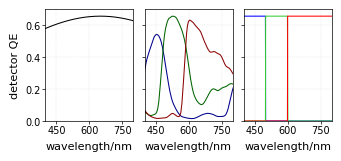

In [16]:
fig, axs = plotter.two_column_plot(width=3.3, height=1.5, ncolumns=3, widthratio=[1,1,1])

x = wavelength
axs[0] = plotter.line_plot(axs=axs[0], x=x, y=R_nonsharp, color='black',
                       xaxislabel='wavelength/nm', yaxislabel='detector QE')

axs[1] = plotter.line_plot(axs=axs[1], x=x, y=B, color='#00008bff')
axs[1] = plotter.line_plot(axs=axs[1], x=x, y=G, color='#006400ff')
axs[1] = plotter.line_plot(axs=axs[1], x=x, y=R, color='#8c0303ff',
                       xaxislabel='wavelength/nm', yaxislabel='detector QE')

x = wavelength
axs[2] = plotter.line_plot(axs=axs[2], x=x, y=B_sharp, color='#0000ffff')
axs[2] = plotter.line_plot(axs=axs[2], x=x, y=G_sharp, color='#32cd32ff')
axs[2] = plotter.line_plot(axs=axs[2], x=x, y=R_sharp, color='#ff0000ff',
                       xaxislabel='wavelength/nm', yaxislabel='detector QE')

for i in np.arange(3):
    axs[i].set_ylim([0, 0.7])
    axs[i].set_xlim([400, 800])
    axs[i].set_xticks([450, 600, 750])
    if i != 0:
        axs[i].set_ylabel('')
    if i != 0:
        axs[i].set_yticklabels('')
    axs[i].tick_params(axis='both', length=2)



#plt.savefig('all_camera_examples.svg', dpi=600, format='svg')


In [ ]:
fig, axs = plotter.one_column_plot(height=3.23/3, width=1.5)


x = wavelength
axs = plotter.line_plot(axs=axs, x=x, y=R_nonsharp, color='black',
                       xaxislabel='wavelength/nm', yaxislabel='detector QE')

axs.set_ylim([0, 0.7])
axs.set_xlim([400, 800])
plt.savefig('standard_camera_example.svg', dpi=600, format='svg')


In [ ]:
fig, axs = plotter.one_column_plot(height=1.5, width=1.5)

x = wavelength
axs = plotter.line_plot(axs=axs, x=x, y=B, color='#00008bff')
axs = plotter.line_plot(axs=axs, x=x, y=G, color='#006400ff')
axs = plotter.line_plot(axs=axs, x=x, y=R, color='#8c0303ff',
                       xaxislabel='wavelength/nm', yaxislabel='detector QE')

axs.set_ylim([0, 0.7])
axs.set_xlim([400, 800])

plt.savefig('bayer_camera_example.svg', dpi=600, format='svg')



In [ ]:
limit_xc_loose = 10
limit_colour_loose = 0.1
limit_xc_tight = 5
limit_colour_tight = 0.05

In [ ]:
#data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = '../../Camera_Calibrations/Ximea_Camera/'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [ ]:
image_size = 20
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [ ]:
n_bootstrap = 20000
background_photons = 40
pixel_size = 69
NA = 1.49

In [ ]:
save_folder = r'/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250729_DyeSuitability'
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [ ]:
import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [ ]:
xc_loose = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
xc_tight = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
colour_loose = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
colour_tight = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
xc_precision = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
colour_precision = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))

In [ ]:
for dyeval in np.arange(len(single_molecule_dataset)):
    dyevalue = single_molecule_dataset['dye'].to_numpy()[dyeval]
    if dyevalue == 'Abberior Star 488':
        dye = 'Alexa Fluor 488'
    else:
        dye = dyevalue
    photonvalue = single_molecule_dataset['photons'].to_numpy()[dyeval]
    print("Analysing dye {}".format(dye), end="\r",flush=True,)        
    MSF.test_fit_method(
                        dye,
                        [],
                        wavelength,
                        camera_parameters,
                        save_folder,
                        np.array([photonvalue]),
                        smoothing_function=smoothing_function,
                        starting_flag="testingdyesuitability_",
                        n_bootstrap=n_bootstrap,
                        background_photons=background_photons,
                        NA=NA,
                        pixel_size=pixel_size,
                        cpu_fraction=1,
                    )
    analysis_files = os.listdir(save_folder)
    mean_wrongness = [os.path.join(save_folder, x) for x in analysis_files if 'RMSE_mean' in x]
    data = pl.read_csv(mean_wrongness[0])
    loc_prec = 0.5*float(data['xc'].to_numpy()[0] + data['yc'].to_numpy()[0])
    colour_prec = float(data['colour_distance'].to_numpy()[0])
    xc_precision[dyeval] = loc_prec
    colour_precision[dyeval] = colour_prec
    if loc_prec < limit_xc_loose:
        xc_loose[dyeval] = 1
    if loc_prec < limit_xc_tight:
        xc_tight[dyeval] = 1
    if colour_prec < limit_colour_loose:
        colour_loose[dyeval] = 1
    if colour_prec < limit_colour_tight:
        colour_tight[dyeval] = 1
    for file in analysis_files:
        os.remove(os.path.join(save_folder, file))

In [ ]:
columns = ['dye', 'photons', 'QY', 'corrected_photons', 'precision_10nm', 'precision_5nm', 'colour_10perc', 'colour_5perc']
data = {}
data['dye'] = single_molecule_dyes[:, 0]
data['photons'] = np.asarray(single_molecule_dyes[:, 1], dtype=np.float32)
data['QY'] = np.asarray(single_molecule_dyes[:, 2], dtype=np.float32)
data['corrected_photons'] = np.asarray(corrected_photons, dtype=np.float32)
data['precision_10nm'] = np.asarray(xc_loose, dtype=np.uint8)
data['precision_5nm'] = np.asarray(xc_tight, dtype=np.uint8)
data['colour_10perc'] = np.asarray(colour_loose, dtype=np.uint8)
data['colour_5perc'] = np.asarray(colour_tight, dtype=np.uint8)
data['xc_precision'] = xc_precision
data['colour_precision'] = colour_precision

single_molecule_dataset = pl.DataFrame(data=data)
single_molecule_dataset.write_csv('Photons_Per_Dye_BetterCamera_Calib.csv')

In [ ]:
R, G, B, wavelength = S_F.getpixelefficiency('../../Spectra/Camera_QE/CS505CU_QE.csv')

In [ ]:
factor = 0.95 / np.max(G)

In [ ]:
Rbetter = R*factor
Gbetter = G*factor
Bbetter = B*factor

In [ ]:
image_size = 20
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
wavelength = wavelength
pixel_QYs = np.vstack([Bbetter, Gbetter, Rbetter])
camera_parameters = {}
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [ ]:
for dyeval in np.arange(len(single_molecule_dataset)):
    dye = single_molecule_dataset['dye'].to_numpy()[dyeval]
    if dye == 'Abberior Star 488':
        dyestr = 'Alexa Fluor 488'
    else:
        dyestr = dye
    photonval = single_molecule_dataset['photons'].to_numpy()[dyeval]
    _, efficiency = S_F.get_pixel_fractions_dye_and_filters(dyes=dyestr, filters=[], wavelength=wavelength, pixel_QYs=np.vstack([Rbetter, Gbetter, Gbetter, Bbetter]))
    corrected_photons[dyeval] = np.mean(photonval * efficiency)

In [ ]:
columns = ['dye', 'photons', 'QY', 'corrected_photons']
data = {}
data['dye'] = single_molecule_dyes[:, 0]
data['photons'] = np.asarray(single_molecule_dyes[:, 1], dtype=np.float32)
data['QY'] = np.asarray(single_molecule_dyes[:, 2], dtype=np.float32)
data['corrected_photons'] = np.asarray(corrected_photons, dtype=np.float32)
single_molecule_dataset = pl.DataFrame(data=data)
single_molecule_dataset.write_csv('Photons_Per_Dye_BetterCamera.csv')

In [ ]:
xc_loose = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
xc_tight = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
colour_loose = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
colour_tight = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
xc_precision = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))
colour_precision = np.zeros(len(single_molecule_dataset['dye'].to_numpy()))

In [ ]:
for dyeval in np.arange(len(single_molecule_dataset)):
    dyevalue = single_molecule_dataset['dye'].to_numpy()[dyeval]
    if dyevalue == 'Abberior Star 488':
        dye = 'Alexa Fluor 488'
    else:
        dye = dyevalue
    photonvalue = single_molecule_dataset['photons'].to_numpy()[dyeval]
    print("Analysing dye {}".format(dye), end="\r",flush=True,)        
    MSF.test_fit_method(
                        dye,
                        [],
                        wavelength,
                        camera_parameters,
                        save_folder,
                        np.array([photonvalue]),
                        smoothing_function=smoothing_function,
                        starting_flag="testingdyesuitability_",
                        n_bootstrap=n_bootstrap,
                        background_photons=background_photons,
                        NA=NA,
                        pixel_size=pixel_size,
                        cpu_fraction=1,
                    )
    analysis_files = os.listdir(save_folder)
    mean_wrongness = [os.path.join(save_folder, x) for x in analysis_files if 'RMSE_mean' in x]
    data = pl.read_csv(mean_wrongness[0])
    loc_prec = 0.5*float(data['xc'].to_numpy()[0] + data['yc'].to_numpy()[0])
    colour_prec = float(data['colour_distance'].to_numpy()[0])
    xc_precision[dyeval] = loc_prec
    colour_precision[dyeval] = colour_prec
    if loc_prec < limit_xc_loose:
        xc_loose[dyeval] = 1
    if loc_prec < limit_xc_tight:
        xc_tight[dyeval] = 1
    if colour_prec < limit_colour_loose:
        colour_loose[dyeval] = 1
    if colour_prec < limit_colour_tight:
        colour_tight[dyeval] = 1
    for file in analysis_files:
        os.remove(os.path.join(save_folder, file))

In [ ]:
columns = ['dye', 'photons', 'QY', 'corrected_photons', 'precision_10nm', 'precision_5nm', 'colour_10perc', 'colour_5perc']
data = {}
data['dye'] = single_molecule_dyes[:, 0]
data['photons'] = np.asarray(single_molecule_dyes[:, 1], dtype=np.float32)
data['QY'] = np.asarray(single_molecule_dyes[:, 2], dtype=np.float32)
data['corrected_photons'] = np.asarray(corrected_photons, dtype=np.float32)
data['precision_10nm'] = np.asarray(xc_loose, dtype=np.uint8)
data['precision_5nm'] = np.asarray(xc_tight, dtype=np.uint8)
data['colour_10perc'] = np.asarray(colour_loose, dtype=np.uint8)
data['colour_5perc'] = np.asarray(colour_tight, dtype=np.uint8)
data['xc_precision'] = xc_precision
data['colour_precision'] = colour_precision

single_molecule_dataset = pl.DataFrame(data=data)
single_molecule_dataset.write_csv('Photons_Per_Dye_BetterCamera_Calib.csv')